# 11주차_강화 학습과 게임 지능

- Preview
- 강화 학습의 원리와 응용
- 최적 정책과 가치 함수
- 동적 프로그래밍
- 학습 기반 알고리즘
- DQN
- 강화 학습과 강한 인공지능

---

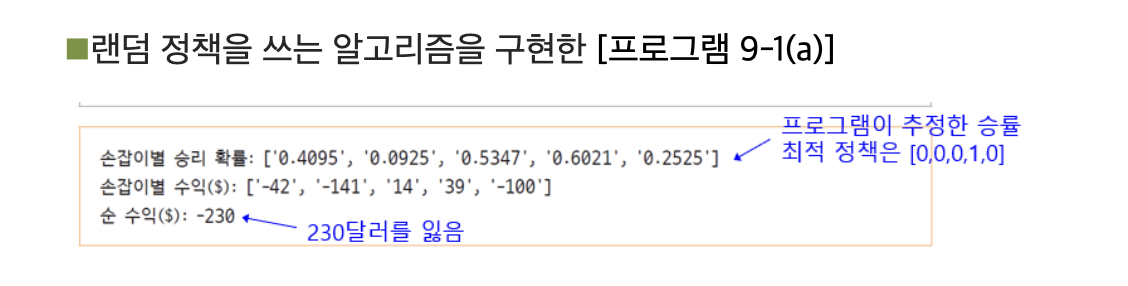

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 다중 손잡이 밴딧(Multi-Armed Bandit) 문제를 기반으로,
# 랜덤 탐색(Random Exploration) 정책 하에 손잡이를 반복적으로 선택하고 보상을 관찰하는 시뮬레이션을 구현함.
# 손잡이 별 보상 확률에 따라 선택 행동을 수행하고, 각 손잡이의 승리 확률 및 누적 수익을 계산함.
# 이는 강화학습 문제 중 '탐험과 이용(Exploration vs Exploitation)'의 기초 개념 학습에 유용한 실습 예제임.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 손잡이 보상 확률 정의 및 시뮬레이션 파라미터 설정
# 2단계: 특정 손잡이를 선택하면 보상을 반환하는 밴딧 환경 함수 정의
# 3단계: 무작위 정책(random policy)을 통한 행동 수행 및 보상 관측
# 4단계: 에피소드 결과 분석 – 손잡이 별 승률, 수익, 총 수익 계산 및 출력
# ------------------------------------------------------------

import numpy as np  # 고속 수치 연산을 위한 패키지로, 확률 샘플링 및 배열 계산을 위해 사용함

# ------------------------------------------------------------
# [1단계] 밴딧 환경 및 시뮬레이션 파라미터 설정
# ------------------------------------------------------------

arms_profit = [0.4, 0.12, 0.52, 0.6, 0.25]  
# 각 손잡이별 보상 확률을 정의한 리스트
# 예를 들어 0번 손잡이는 40% 확률로 보상을 제공하며, 나머지는 실패함
# 강화학습에서는 환경의 보상 분포를 정의하는 핵심 구성 요소임

n_arms = len(arms_profit)  
# 총 손잡이의 개수를 계산한 값으로, 실험에서 사용할 행동 선택 공간의 크기를 의미함

n_trial = 10000  
# 손잡이를 반복적으로 당기는 횟수를 의미하는 파라미터
# 학습 또는 평가가 진행될 총 시뮬레이션 단계 수를 나타냄

# ------------------------------------------------------------
# [2단계] 밴딧 환경 함수 정의
# ------------------------------------------------------------

def pull_bandit(handle):  
    # 특정 손잡이(handle)를 선택했을 때 보상을 반환하는 함수 정의
    # 입력값은 손잡이 인덱스이며, 반환값은 보상(1 또는 -1)임

    q = np.random.random()  
    # 0 이상 1 미만의 난수를 무작위로 생성하여 확률적 보상 여부를 결정함

    if q < arms_profit[handle]:  
        # 난수 값이 해당 손잡이의 보상 확률보다 작으면 보상 발생으로 간주함
        return 1  # 보상을 받은 경우에는 1을 반환함
    else:
        return -1  # 보상을 받지 못한 경우에는 -1을 반환함

# ------------------------------------------------------------
# [3단계] 랜덤 탐색 정책 함수 정의
# ------------------------------------------------------------

def random_exploration():  
    # 모든 손잡이를 동일 확률로 무작위 선택하며 보상을 관측하는 함수 정의
    # 정책(policy) 없이 탐험(exploration)만 수행하는 순수 랜덤 전략임

    episode = []  
    # 각 시뮬레이션 단계의 결과를 저장할 리스트
    # 각 항목은 [선택한 손잡이, 받은 보상]으로 구성됨

    num = np.zeros(n_arms)  
    # 손잡이별로 선택된 횟수를 저장하는 배열
    # 선택 빈도수를 통계적으로 집계하기 위함임

    wins = np.zeros(n_arms)  
    # 손잡이별로 보상을 받은 횟수를 저장하는 배열
    # 승률 계산을 위한 누적 보상 횟수를 추적함

    for i in range(n_trial):  
        # 전체 시뮬레이션 반복 횟수만큼 루프 수행

        h = np.random.randint(0, n_arms)  
        # 손잡이 중 무작위로 하나를 선택함 (0 이상 n_arms 미만의 정수 선택)

        reward = pull_bandit(h)  
        # 선택한 손잡이에 대해 보상을 얻기 위해 밴딧 환경 함수를 호출함

        episode.append([h, reward])  
        # 시뮬레이션 결과를 에피소드에 기록함 (선택한 손잡이 번호, 받은 보상)

        num[h] += 1  
        # 해당 손잡이의 선택 횟수를 1 증가시킴

        wins[h] += 1 if reward == 1 else 0  
        # 보상을 받았다면 해당 손잡이의 승리 횟수를 1 증가시킴

    return episode, (num, wins)  
    # 전체 에피소드와 손잡이별 선택 횟수 및 승리 횟수 통계를 반환함

# ------------------------------------------------------------
# [4단계] 실험 수행 및 결과 분석
# ------------------------------------------------------------

e, r = random_exploration()  
# 랜덤 탐색을 수행하고 반환된 결과를 변수 e(에피소드), r(선택/승리 통계)에 저장함

print("손잡이별 승리 확률:", ["%6.4f" % (r[1][i] / r[0][i]) if r[0][i] > 0 else 0.0 for i in range(n_arms)])  
# 각 손잡이에 대해 승리 확률(= 승리 횟수 / 선택 횟수)을 계산하여 소수점 4자리까지 출력함
# 단, 선택된 적이 없는 손잡이는 0으로 처리하여 분모 0 오류를 방지함

print("손잡이별 수익($):", ["%d" % (2 * r[1][i] - r[0][i]) for i in range(n_arms)])  
# 각 손잡이에 대해 총 수익을 계산하여 정수 형태로 출력함
# 수익 계산식: (보상 1달러를 기준으로) 수익 = 2 × 승리 횟수 - 총 선택 횟수
# 이는 승리 시 +1달러, 패배 시 -1달러로 가정한 단순 손익 구조에 기반함

print("순 수익($):", sum(np.asarray(e)[:, 1]))  
# 전체 에피소드의 보상 합계를 통해 순 수익을 계산함
# 모든 손잡이 선택에서 받은 보상(1 또는 -1)의 총합으로 평가함


---

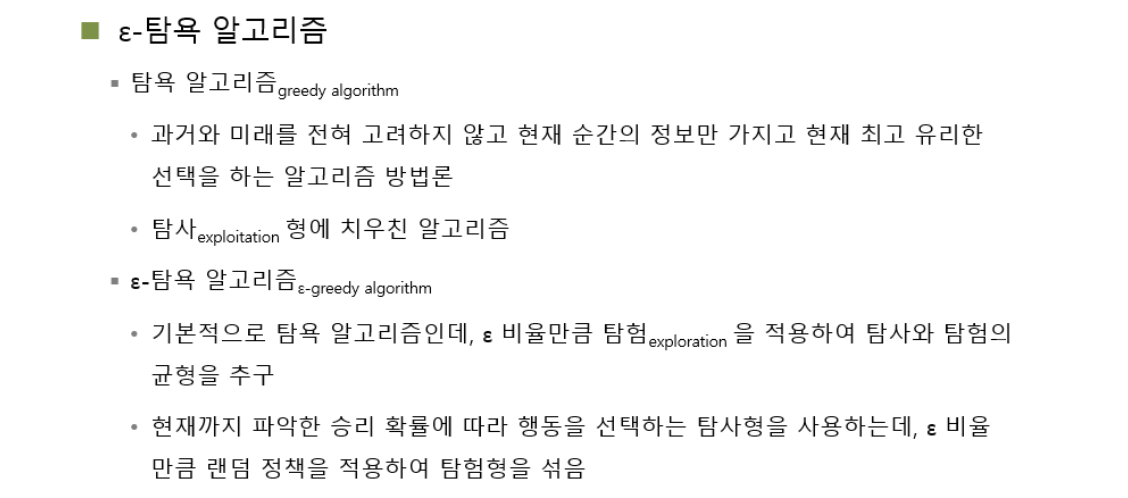

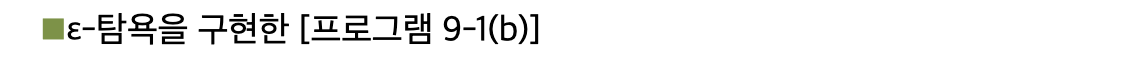

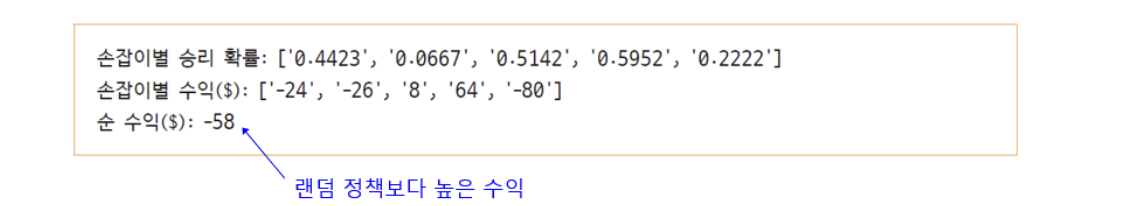

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 다중 손잡이 밴딧(Multi-Armed Bandit) 문제에서 ε-탐욕(Epsilon-Greedy) 전략을 시뮬레이션하는 함수임.
# ε-탐욕은 탐험(exploration)과 이용(exploitation)을 균형 있게 수행하는 대표적인 정책으로,
# 일정 확률(ε)로 무작위 손잡이를 선택하거나, 나머지 확률(1 - ε)로 현재까지 가장 성능이 좋은 손잡이를 선택함.
# 이를 통해 단순 랜덤 정책보다 더 나은 누적 보상을 달성하는 것이 목적임.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 손잡이별 선택 횟수 및 승리 횟수 초기화
# 2단계: 각 반복 단계에서 확률적으로 무작위 또는 승률 기반 손잡이 선택
# 3단계: 보상 관측 및 에피소드 기록, 통계 갱신
# 4단계: 전체 에피소드 및 손잡이별 통계 결과 반환
# ------------------------------------------------------------

# ------------------------------------------------------------
# [ε-탐욕(Epsilon-Greedy) 정책 함수 정의]
# ------------------------------------------------------------

def epsilon_greedy(eps):  
    # 입력값 eps는 무작위 탐험을 수행할 확률(0~1 사이의 값)을 의미함
    # 예: eps=0.1이면 10% 확률로 무작위 탐험, 90% 확률로 이용 전략 수행

    episode = []  
    # 각 반복 단계에서의 [선택한 손잡이 번호, 받은 보상]을 기록하는 리스트 변수

    num = np.zeros(n_arms)  
    # 손잡이별로 지금까지 선택된 횟수를 저장하는 배열
    # 추후 손잡이별 평균 보상(승률)을 계산하는 데 사용됨

    wins = np.zeros(n_arms)  
    # 손잡이별로 보상을 받은 횟수를 저장하는 배열
    # 승률 계산의 분자(누적 성공 횟수)로 사용됨

    for i in range(n_trial):  
        # 전체 시뮬레이션 반복 횟수만큼 루프 수행

        r = np.random.random()  
        # 0 이상 1 미만의 실수 난수를 무작위로 생성하여 탐험 여부를 결정함

        if (r < eps or sum(wins) == 0):  
            # 조건 1: 난수 r이 eps보다 작으면 무작위 탐험 수행
            # 조건 2: 아직 어떤 손잡이도 성공 경험이 없다면(초기 단계) 무작위 선택 수행
            h = np.random.randint(0, n_arms)  
            # 손잡이 중 무작위로 하나를 선택함 (0 이상 n_arms 미만 범위에서 선택)

        else:
            # 탐험이 아닌 이용(exploitation) 전략 수행 시 실행되는 블록

            prob = np.asarray([wins[i] / num[i] if num[i] > 0 else 0.0 for i in range(n_arms)])  
            # 손잡이별로 현재까지의 승률(성공 횟수 / 선택 횟수)을 계산하여 배열로 저장함
            # 단, 아직 선택되지 않은 손잡이는 0으로 처리하여 0으로 간주함

            prob = prob / sum(prob)  
            # 승률 합으로 나누어 확률 분포로 정규화함 (전체 합이 1이 되도록 스케일 조정)

            h = np.random.choice(range(n_arms), p=prob)  
            # 정규화된 승률 분포에 따라 손잡이를 선택함 (확률적으로 가장 잘된 손잡이를 더 자주 선택함)

        reward = pull_bandit(h)  
        # 선택한 손잡이에 대해 밴딧 환경 함수를 호출하여 보상을 관측함

        episode.append([h, reward])  
        # 이번 반복에서 선택한 손잡이 번호와 보상 결과를 에피소드에 기록함

        num[h] += 1  
        # 해당 손잡이의 선택 횟수를 1 증가시켜 통계 갱신

        wins[h] += 1 if reward == 1 else 0  
        # 보상이 1일 경우(성공) 해당 손잡이의 성공 횟수를 1 증가시킴

    return episode, (num, wins)  
    # 전체 시뮬레이션 결과인 에피소드 기록과 손잡이별 선택/성공 통계를 반환함

# ------------------------------------------------------------
# [정책 실행 및 결과 출력]
# ------------------------------------------------------------

e, r = epsilon_greedy(0.1)  
# ε-탐욕 정책을 eps=0.1로 설정하여 실행하고 결과를 변수에 저장함

print("손잡이별 승리 확률:", ["%6.4f" % (r[1][i] / r[0][i]) if r[0][i] > 0 else 0.0 for i in range(n_arms)])  
# 손잡이별 승률(= 성공 횟수 / 선택 횟수)을 소수점 4자리까지 계산하여 출력함
# 선택 횟수가 0인 경우는 0으로 처리하여 오류 방지

print("손잡이별 수익($):", ["%d" % (2 * r[1][i] - r[0][i]) for i in range(n_arms)])  
# 각 손잡이별로 얻은 수익을 계산하고 정수형으로 출력함
# 수익 공식: 수익 = 2 × 성공 횟수 - 전체 선택 횟수 (성공 시 +1, 실패 시 -1 기준의 수익 모델)

print("순 수익($):", sum(np.asarray(e)[:, 1]))  
# 전체 에피소드에서 받은 보상들의 총합을 계산하여 순 수익을 출력함
# np.asarray(e)[:, 1]은 보상만 추출하여 합산함


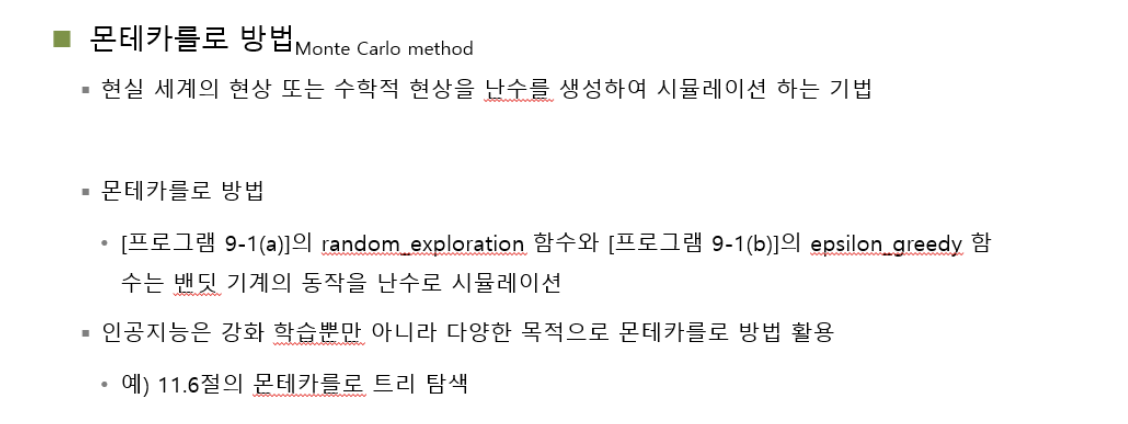

---

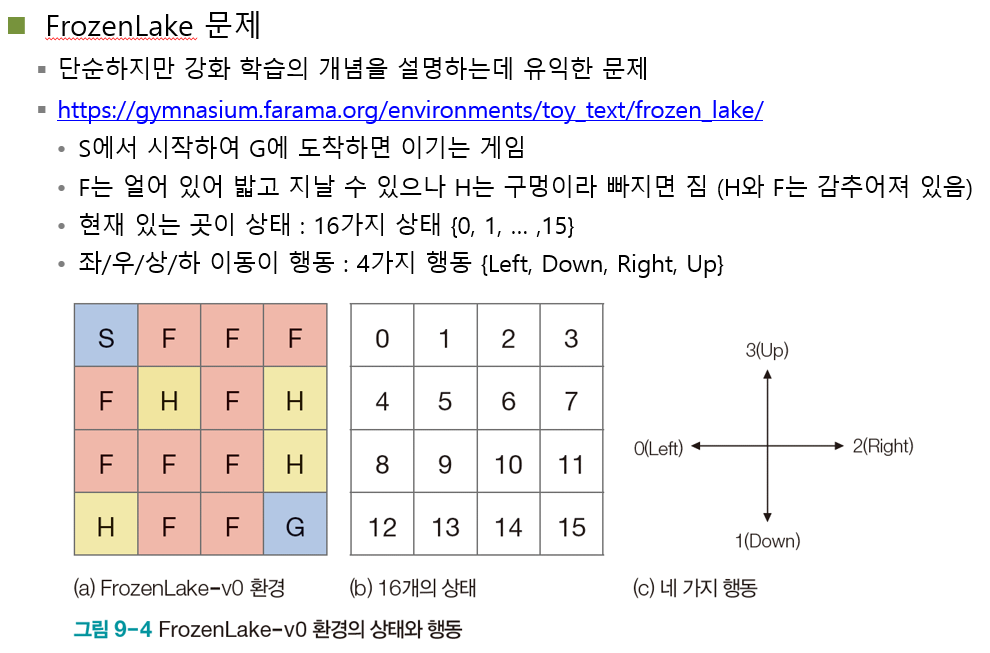

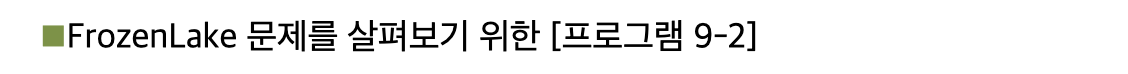

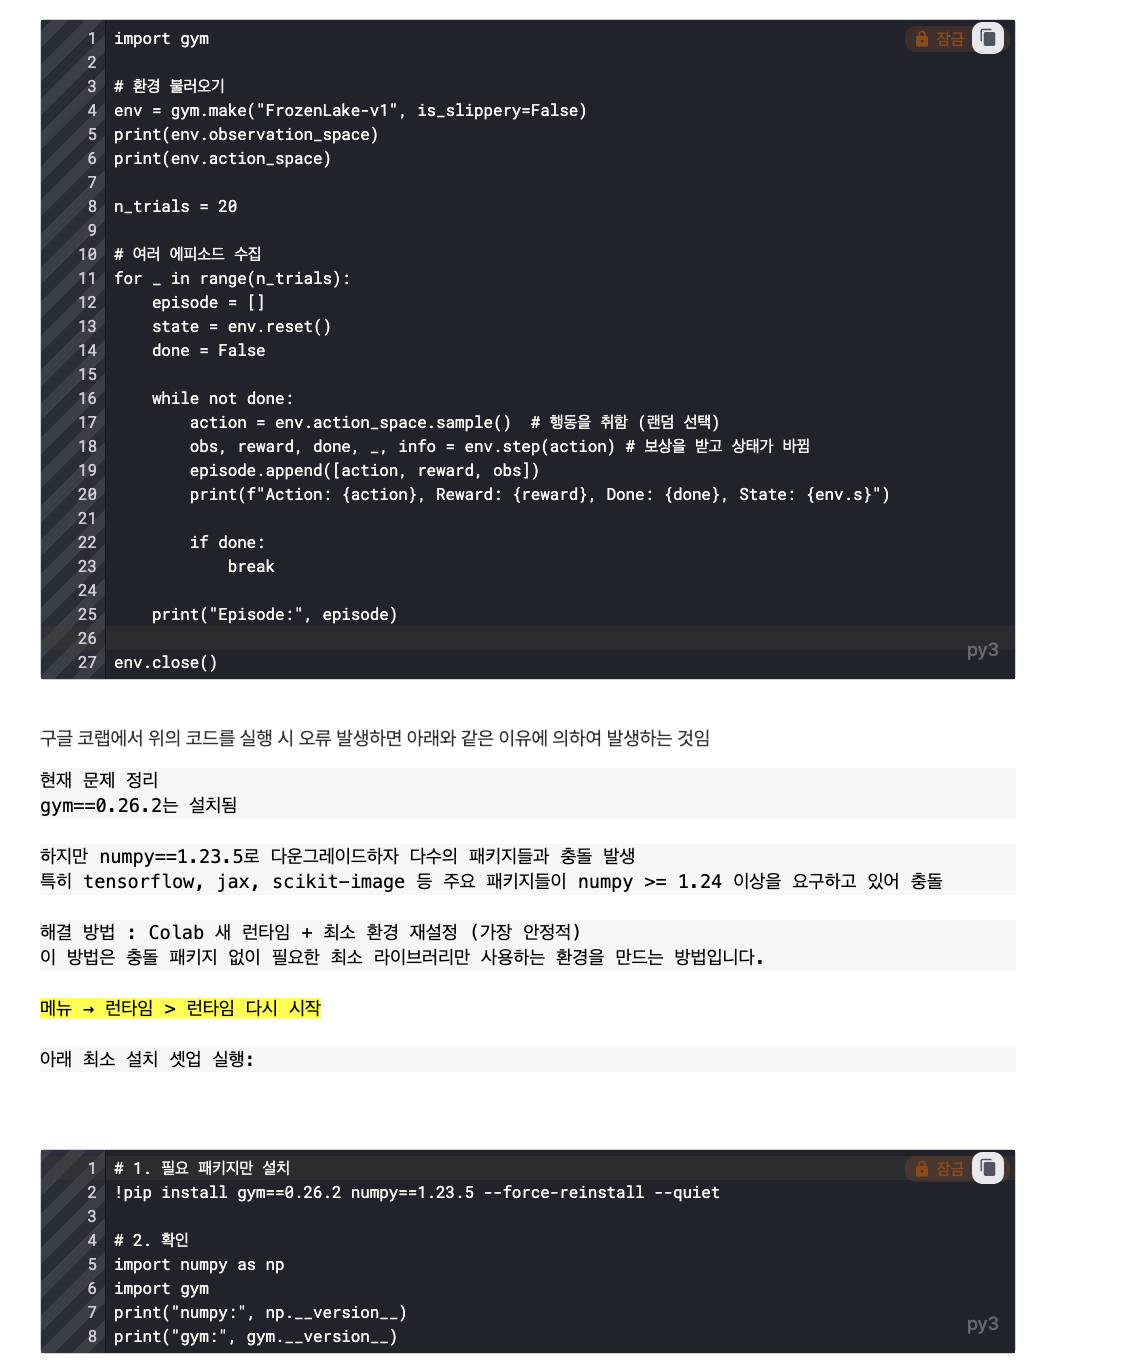

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 강화학습 시뮬레이션 환경인 OpenAI Gym의 FrozenLake-v1을 이용하여,
# 에이전트가 무작위(Random Policy)로 행동을 선택하며 환경과 상호작용하는 과정을 1회 시뮬레이션함.
# FrozenLake는 미끄러운 얼음판 위에서 목표 지점에 도달해야 하는 강화학습 환경이며,
# 이 예제에서는 미끄러짐을 비활성화하여 결정론적(deterministic) 환경으로 설정함.
# 각 상태에서의 행동, 다음 상태, 보상을 기록하며 학습 전 탐색 구조나 환경의 동작 방식을 확인하는 데 활용할 수 있음.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 환경 생성 및 상태/행동 공간 정보 출력
# 2단계: 환경 초기화 및 관측값 초기화
# 3단계: 무작위 정책에 따라 행동 선택 및 환경과 상호작용 반복
# 4단계: 행동 결과 기록 및 중단 조건 확인
# 5단계: 시뮬레이션 종료 및 결과 출력
# ------------------------------------------------------------

import gym  # 강화학습 환경 생성을 위한 OpenAI Gym 라이브러리 불러오기

env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")  
# FrozenLake-v1 환경을 생성하며, is_slippery=False로 설정하여 미끄러짐을 제거함
# render_mode="ansi"를 사용하여 텍스트 기반 출력 가능하도록 설정함
# 즉, 환경 시각화 결과를 문자열 형태로 반환받을 수 있음

print(env.observation_space)  # Discrete(16)  
# 환경의 관측 공간 출력: 총 16개의 상태(state)로 구성된 이산 공간(4x4 격자판)
# 상태 번호는 0~15의 정수로 표현됨

print(env.action_space)  # Discrete(4)  
# 환경의 행동 공간 출력: 총 4개의 행동으로 구성된 이산 공간
# 행동 번호는 0=왼쪽, 1=아래, 2=오른쪽, 3=위쪽을 의미함

n_trial = 20  
# 최대 실행할 시뮬레이션 반복 횟수를 정의함 (에이전트가 행동을 취하는 최대 횟수)

episode = []  
# 에이전트의 행동, 보상, 다음 상태를 기록할 리스트
# 에피소드의 로그를 저장하여 이후 분석 또는 시각화에 활용 가능함

obs, info = env.reset()  
# 환경을 초기화하여 시작 상태를 반환받음
# obs는 시작 상태(정수), info는 환경 초기화 관련 추가 정보를 포함한 딕셔너리

for i in range(n_trial):  
    # 최대 n_trial회 반복하며 환경과 상호작용하는 루프 정의

    action = env.action_space.sample()  
    # 행동 공간에서 무작위로 행동 하나를 샘플링함
    # ε-탐욕 또는 정책 학습 전 무작위 탐색에 해당하는 전략임

    obs, reward, terminated, truncated, info = env.step(action)  
    # 선택한 행동을 환경에 적용하고 그에 따른 결과를 반환받음
    # obs: 다음 상태 / reward: 보상 / terminated: 목표 도달 또는 실패 여부
    # truncated: 시간 제한 초과 여부 / info: 기타 진단 정보

    episode.append([action, reward, obs])  
    # 현재 반복에서 수행한 행동, 얻은 보상, 도달한 상태를 기록함

    print(env.render())  
    # 현재 상태의 텍스트 기반 시각화를 출력함
    # 격자 상태에서 에이전트 위치와 환경 구조를 ASCII 문자로 표현함

    if terminated or truncated:  
        # 목표 도달 또는 제한 조건 도달 시 루프를 중단함
        # 강화학습에서 에피소드 종료 조건을 감지하는 로직임
        break

print(episode)  
# 전체 에피소드에 대해 수행한 기록(행동, 보상, 상태)를 출력함
# 학습 없이 무작위로 얻은 행동 결과를 확인하는 데 사용함

env.close()  
# 환경을 닫아 자원 해제를 수행함
# 그래픽 환경에서는 창을 닫는 역할도 수행함

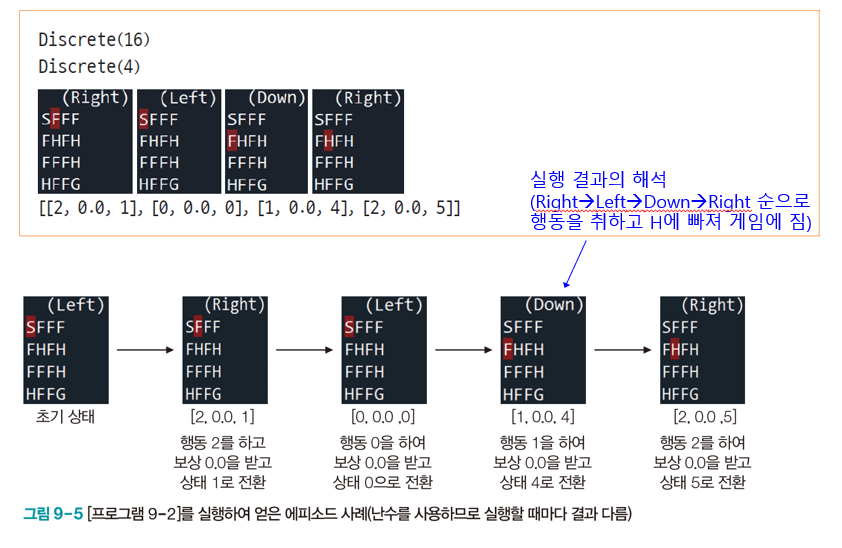

---

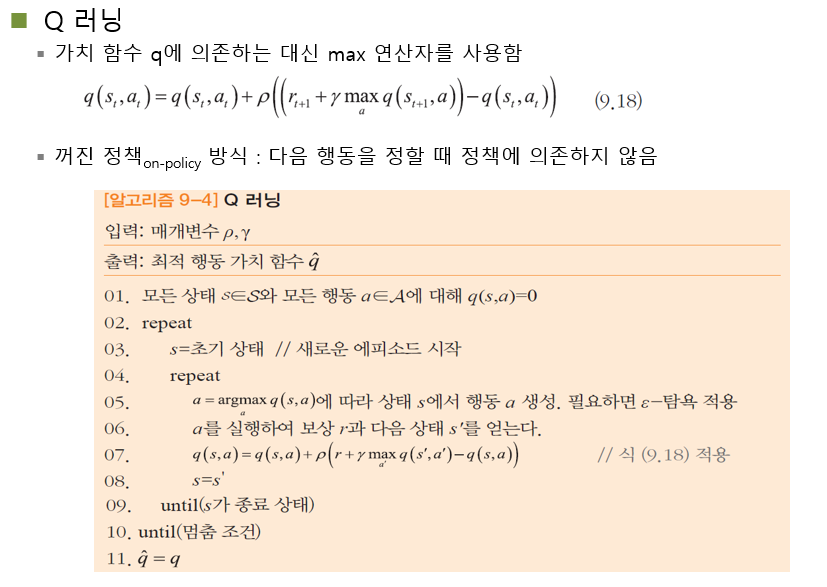

### Q-learning 코드 이해를 위한 쉬운 개념 정리 표

| 용어 | 쉬운 설명 |
| --- | --- |
| **강화학습 (Reinforcement Learning)** | 어떤 상황에서 무엇을 하면 좋을지를 스스로 알아가는 컴퓨터 학습 방법임. 정해진 답이 없고, 행동에 따라 잘했는지 못했는지를 숫자로 보상을 받으며 배우는 방식임 |
| **환경 (Environment)** | 에이전트가 활동하는 공간임. FrozenLake에서는 얼음판이 환경이고, 각 칸마다 물이거나 목표 지점이거나 시작 위치일 수 있음 |
| **에이전트 (Agent)** | 환경 속에서 움직이며 목표를 향해 나아가는 주체임. 코드에서는 Q 테이블을 참고해 방향을 정하고 보상을 받는 역할임 |
| **상태 (State)** | 현재 에이전트가 환경에서 어디에 있는지를 나타내는 정보임. FrozenLake에서는 0부터 15까지 숫자로 각 칸의 위치를 표현함 |
| **행동 (Action)** | 에이전트가 현재 위치에서 할 수 있는 움직임임. FrozenLake에서는 왼쪽(0), 아래(1), 오른쪽(2), 위(3)의 네 가지 방향이 있음 |
| **보상 (Reward)** | 행동을 했을 때 주어지는 점수임. 목적지에 도달하면 1점을 받고, 그렇지 않으면 0점을 받음. 이 보상을 바탕으로 어떤 행동이 좋은지를 학습함 |
| **에피소드 (Episode)** | 한 번 시작해서 끝날 때까지의 과정을 의미함. 시작 상태에서 출발하여 구멍에 빠지거나 목적지에 도달하면 하나의 에피소드가 끝남 |
| **Q 테이블 (Q-table)** | 상태와 행동의 조합별로 얼마나 좋은지를 저장하는 표임. 숫자가 클수록 그 행동이 좋다는 의미이며, 이 표를 계속 업데이트하면서 학습이 이루어짐 |
| **학습률 (Learning Rate, ρ)** | 새로 받은 보상이 기존의 Q 값에 얼마나 영향을 줄지를 정하는 비율임. 1에 가까우면 새 정보를 많이 반영하고, 0에 가까우면 기존 값을 유지함 |
| **할인율 (Discount Factor, λ)** | 미래 보상이 현재의 가치에 얼마나 영향을 주는지를 나타내는 비율임. 1에 가까울수록 먼 미래의 보상도 중요하게 여김 |
| **탐욕 정책 (Greedy Policy)** | 항상 현재 Q 테이블에서 가장 높은 값을 가진 행동만을 선택하는 전략임. 학습 후반에는 탐험보다는 이 정책으로 최적 행동을 수행함 |
| **탐험 (Exploration)** | 아직 잘 모르는 행동도 시도해보는 것임. 탐험을 통해 다양한 행동의 보상을 확인할 수 있음. 이 코드에서는 탐험 없이 학습함 |
| **Q-learning** | 행동을 통해 받은 보상과 다음 상태의 예측 가치를 바탕으로 Q 테이블을 업데이트하는 알고리즘임. 가장 많이 쓰이는 강화학습 방법 중 하나임 |

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 OpenAI Gym의 FrozenLake-v1 환경을 기반으로,
# Q-learning 알고리즘을 이용하여 최적의 상태-행동 가치 함수(Q-table)를 학습하는 예제임.
# 환경은 미끄러짐(slippery) 없는 결정론적 환경으로 구성되며,
# 각 에피소드에서 에이전트는 탐험 없이 항상 현재 Q값이 최대인 행동을 선택함(탐욕 정책).
# 학습이 완료된 후에는 상태별 최적 행동이 반영된 Q 테이블을 출력함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: FrozenLake 환경 생성 및 Q 테이블 초기화
# 2단계: 학습률(ρ), 할인율(λ), 반복 횟수 설정
# 3단계: 다수 에피소드 반복을 통해 Q 값 업데이트 수행
#   └ 각 상태에서 Q-값이 가장 큰 행동을 선택하여 수행
#   └ 보상 + 다음 상태의 최대 Q 값을 이용해 Q 갱신
# 4단계: 최종 Q 테이블 출력
# ------------------------------------------------------------

import gym  # 강화학습 환경 생성을 위한 OpenAI Gym 라이브러리 임포트
import numpy as np  # 수치 연산을 위한 고성능 배열 처리 라이브러리 임포트

env = gym.make('FrozenLake-v1', is_slippery=False)  
# 'FrozenLake-v1' 환경 생성
# is_slippery=False 옵션으로 인해 환경이 결정론적으로 동작하며, 미끄러짐이 없음

Q = np.zeros([env.observation_space.n, env.action_space.n])  
# Q 테이블 초기화 (행: 상태 수, 열: 행동 수)
# 각 셀은 해당 상태에서 행동을 취했을 때의 기대 보상값을 의미함

rho = 0.8  
# 학습률(learning rate, ρ)을 설정함
# 새로운 정보가 기존 Q 값에 얼마나 영향을 줄지를 결정함

lamda = 0.99  
# 할인율(discount factor, λ)을 설정함
# 미래 보상에 대한 현재 가치의 가중치를 결정하며, 0에 가까울수록 당장 보상에 집중함

n_episode = 2000  
# 총 에피소드 반복 횟수 설정 (총 2000번의 독립된 시뮬레이션을 실행함)

length_episode = 100  
# 각 에피소드 당 최대 반복 횟수를 설정함
# 지정된 횟수 이상으로 진행되는 것을 방지함 (무한 루프 방지용)

# ------------------------------------------------------------
# [Q-learning 알고리즘을 통한 최적 정책 학습]
# ------------------------------------------------------------

for i in range(n_episode):  
    # 전체 에피소드를 반복하며 Q 값을 업데이트하는 루프 정의

    s, _ = env.reset()  
    # 환경 초기화 후 시작 상태(observation)를 s에 저장
    # Gym 최신 버전에서는 (state, info) 튜플을 반환하므로 info는 무시함

    for j in range(length_episode):  
        # 한 에피소드 안에서 에이전트가 행동을 수행하는 루프

        argmaxs = np.argwhere(Q[s, :] == np.amax(Q[s, :])).flatten().tolist()  
        # 현재 상태 s에서 Q 값이 최대인 행동(복수 가능성 포함)을 추출함
        # np.argmax는 하나만 반환하지만, 동률이 존재할 수 있으므로 argwhere를 사용함

        a = np.random.choice(argmaxs)  
        # 최대 Q 값을 갖는 행동 중 무작위로 하나를 선택함 (탐욕 정책 but 무작위성 보존)

        s1, r, terminated, truncated, _ = env.step(a)  
        # 선택한 행동 a를 환경에 적용하고 다음 상태, 보상, 종료 여부 등을 관측함
        # s1: 다음 상태 / r: 보상 / terminated: 정상 종료 / truncated: 시간 초과

        done = terminated or truncated  
        # 에피소드 종료 여부를 하나의 변수로 통합하여 처리함

        Q[s, a] = Q[s, a] + rho * (r + lamda * np.max(Q[s1, :]) - Q[s, a])  
        # Q-learning 갱신 식 적용: Q(s,a) ← Q(s,a) + ρ[r + λ * max_a' Q(s',a') - Q(s,a)]
        # 현재 상태-행동 쌍의 Q 값을 보상 및 다음 상태의 최적 Q 값을 바탕으로 업데이트함

        s = s1  
        # 현재 상태를 다음 상태로 업데이트하여 다음 반복 단계로 이동함

        if done:  
            # 에피소드 종료 조건이 만족되면 현재 루프를 탈출함
            break

# ------------------------------------------------------------
# [학습된 Q 테이블 출력]
# ------------------------------------------------------------

np.set_printoptions(precision=2)  
# 배열 출력 시 소수점 둘째 자리까지만 표시하도록 설정함

print(Q)  
# 학습이 완료된 상태-행동 가치 함수(Q 테이블)를 출력함
# 이 테이블을 통해 각 상태에서 어떤 행동이 최적인지 해석 가능함


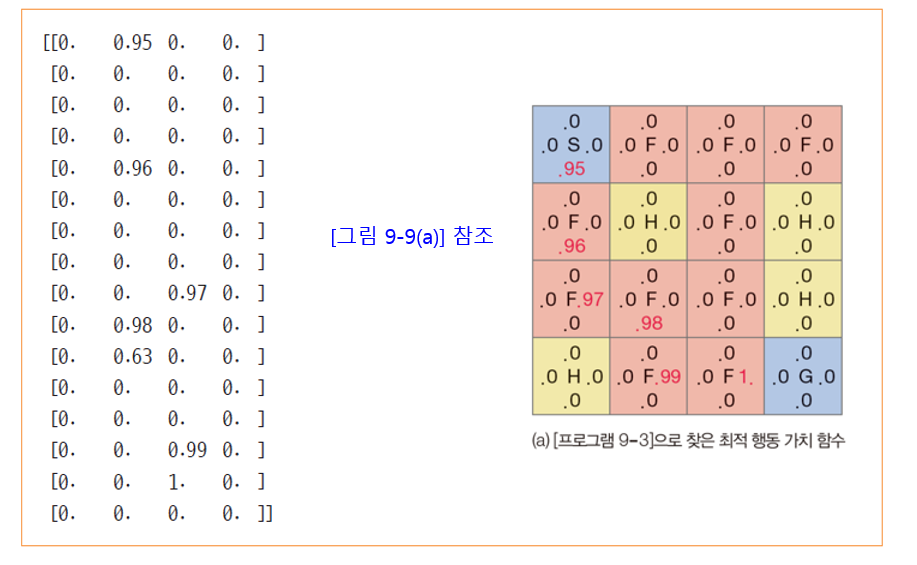

---

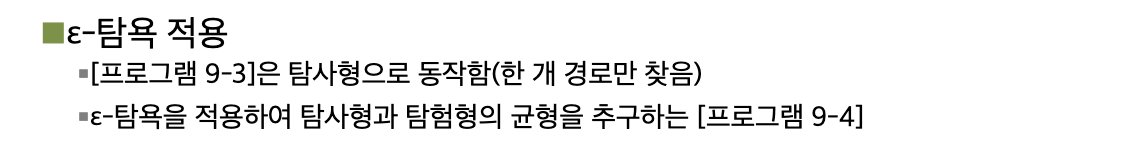

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 OpenAI Gym의 FrozenLake-v1 환경에서 Q-learning 알고리즘을 기반으로,
# ε-탐욕 정책을 활용하여 최적의 상태-행동 가치 함수(Q-table)를 학습하는 강화학습 시뮬레이션임.
# 초기에는 높은 ε 값으로 탐험(exploration)을 많이 하고, 시간이 지날수록 ε 값을 점진적으로 감소시켜
# 최적 행동(exploitation)에 집중하는 방식으로 탐사-탐험의 균형을 유도함.
# 학습이 완료된 후에는 상태별 최적 행동 선택에 대한 Q 테이블이 출력됨.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: FrozenLake 환경 생성 및 Q 테이블 초기화
# 2단계: 하이퍼파라미터(학습률, 할인율, 초기 ε, ε 감소율 등) 정의
# 3단계: 각 에피소드마다 상태 초기화 후 반복 학습 수행
#   └ ε 값에 따라 무작위 행동 또는 최적 행동 선택
#   └ Q 테이블 업데이트
# 4단계: 학습 완료 후 최종 Q 테이블 출력
# ------------------------------------------------------------

import gym  # 강화학습 환경 생성을 위한 OpenAI Gym 라이브러리 임포트
import numpy as np  # 배열 기반의 수치 연산을 위한 라이브러리 임포트

env = gym.make('FrozenLake-v1', is_slippery=False)  
# 'FrozenLake-v1' 환경 생성
# is_slippery=False로 설정하여 미끄러짐 없는 결정론적 환경 구성

Q = np.zeros([env.observation_space.n, env.action_space.n])  
# 상태(state)-행동(action) 쌍에 대한 Q 테이블을 0으로 초기화
# 행: 상태 수(16), 열: 행동 수(4), 각 셀은 Q(s,a) 값 의미

rho = 0.90  
# 학습률(ρ): 새로 관측된 보상이 기존 Q 값에 미치는 영향을 조절하는 계수

lamda = 0.99  
# 할인율(λ): 미래 보상에 대한 현재 가치 반영 비율
# 1에 가까울수록 먼 미래의 보상도 중요하게 고려함

eps = 1.0  
# 초기 ε 값 설정 (탐험 확률 100%)
# 시작 시 모든 행동을 고르게 시도하도록 설정함

eps_decay = 0.999  
# ε 값을 에피소드마다 점진적으로 줄이기 위한 감소율
# 반복이 진행될수록 점차 최적 행동 위주로 전환됨

n_episode = 3000  
# 총 에피소드 수 (학습 반복 횟수)를 3000으로 설정

length_episode = 100  
# 한 에피소드당 최대 반복 횟수를 100으로 설정
# 제한된 횟수 내에서 목표 지점 도달 실패 시 에피소드 종료됨

# ------------------------------------------------------------
# [Q-learning 알고리즘 + ε-탐욕 탐사 정책 적용]
# ------------------------------------------------------------

for i in range(n_episode):  
    # 총 n_episode 횟수만큼 학습 반복

    s = env.reset()  
    # 새로운 에피소드 시작 시 초기 상태를 받아옴
    # Gym 최신 버전에서는 (obs, info) 튜플 반환, info 무시

    for j in range(length_episode):  
        # 에피소드 내에서 반복하여 행동 수행

        r = np.random.random()  
        # 0 이상 1 미만의 실수형 난수를 무작위로 생성함
        # 탐험 여부 판단에 사용됨

        eps = max(0.01, eps * eps_decay)  
        # ε 값을 감소시키되, 최소값은 0.01로 고정하여 완전한 탐험 소멸을 방지함

        if r < eps:  
            # 무작위 수가 ε보다 작으면 탐험 수행
            a = np.random.randint(0, env.action_space.n)  
            # 행동 공간에서 무작위로 행동 하나를 선택함

        else:
            # ε보다 크면 현재 Q 테이블 기준으로 최적 행동을 선택함

            argmaxs = np.argwhere(Q[s, :] == np.amax(Q[s, :])).flatten().tolist()  
            # 현재 상태 s에서 Q 값이 최대인 행동의 인덱스를 모두 추출함
            # argmax 결과가 다수일 수 있어 argwhere 사용

            a = np.random.choice(argmaxs)  
            # 최대 Q 값을 갖는 후보들 중 하나를 무작위로 선택함

        s1, r, done, _, info_ = env.step(a)  
        # 선택한 행동 a를 환경에 적용하고 다음 상태, 보상, 종료 여부를 관측함
        # s1: 다음 상태 / r: 보상 / done: 종료 여부 / info_: 기타 정보

        Q[s, a] = Q[s, a] + rho * (r + lamda * np.max(Q[s1, :]) - Q[s, a])  
        # Q-learning 갱신 식 적용
        # Q(s,a) ← Q(s,a) + ρ * [r + λ * max_a' Q(s', a') - Q(s,a)]

        s = s1  
        # 현재 상태를 다음 상태로 업데이트하여 다음 반복에 사용함

        if done:  
            # 종료 조건(목표 도달 or 실패) 만족 시 에피소드 탈출
            break

# ------------------------------------------------------------
# [학습 결과 출력: Q 테이블]
# ------------------------------------------------------------

np.set_printoptions(precision=2)  
# Q 테이블 출력 시 소수점 둘째 자리까지 표시하도록 설정함

print(Q)  
# 최종 학습된 상태-행동 가치 함수(Q 테이블)를 출력함
# 각 상태에서 어떤 행동


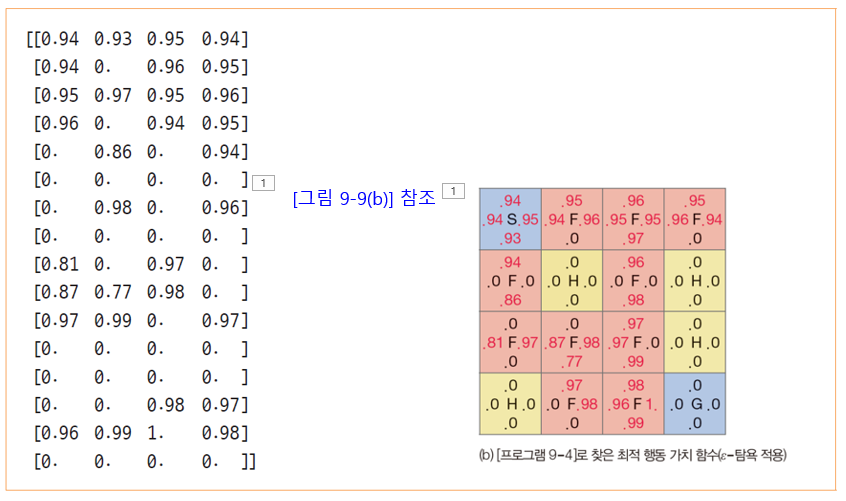

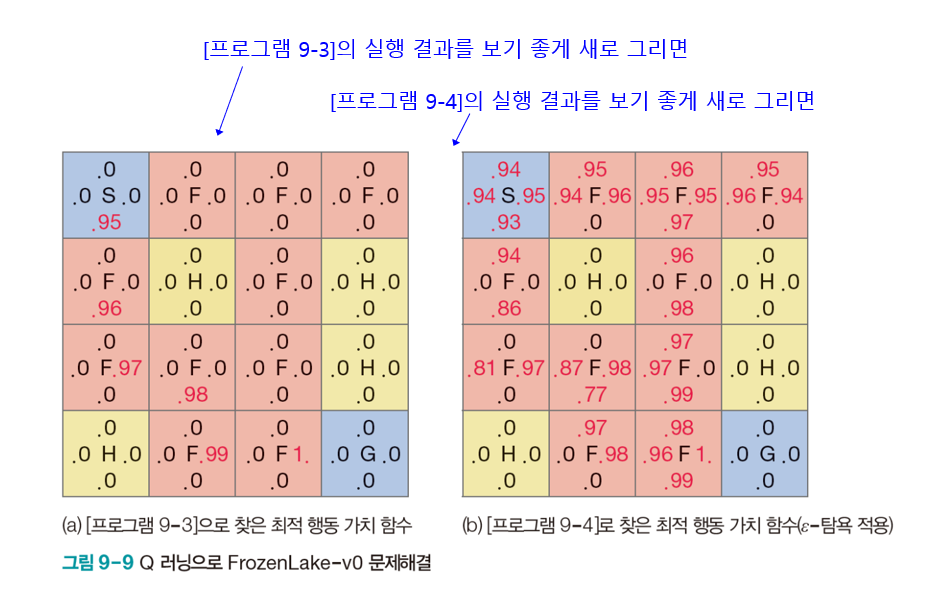

---

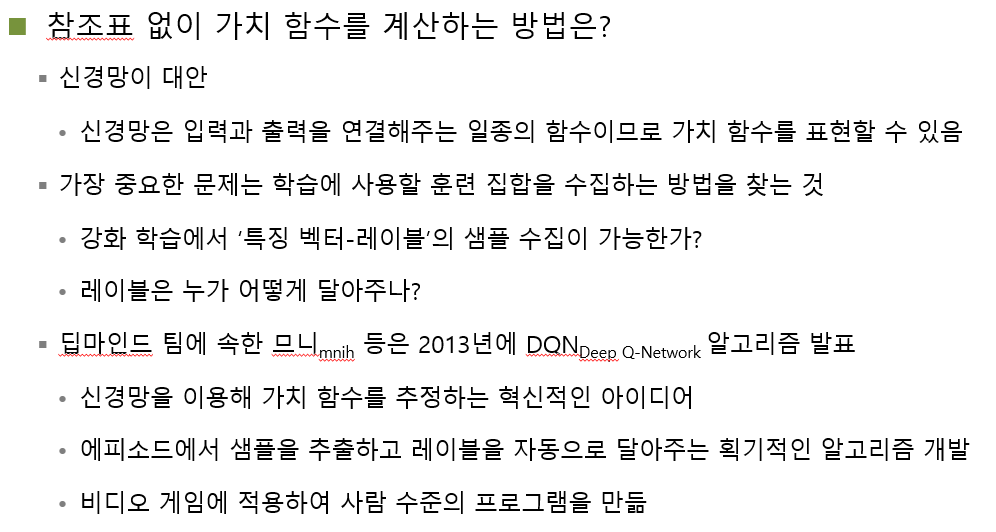

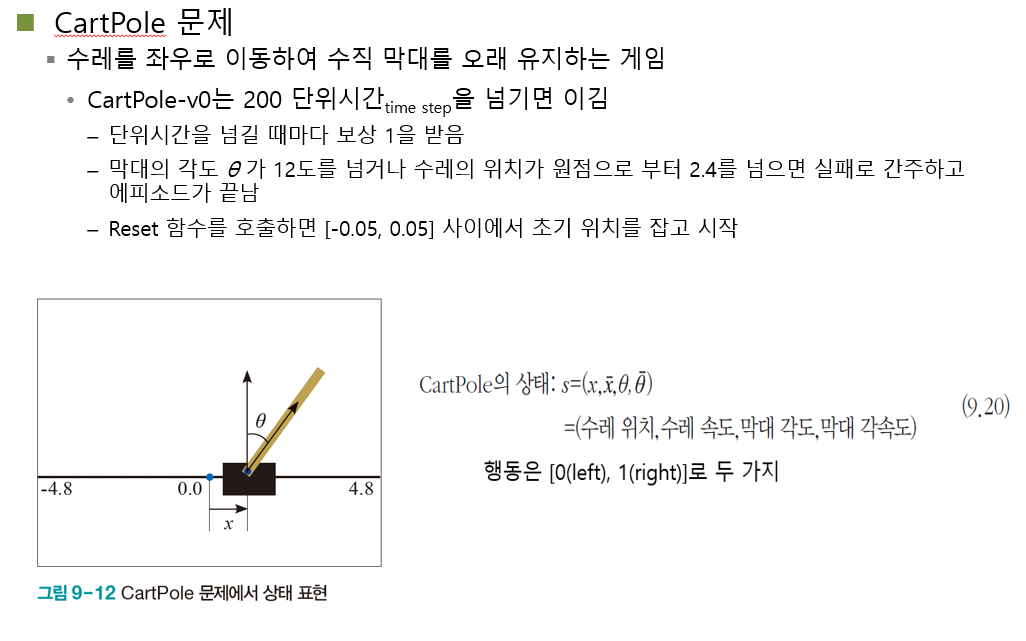

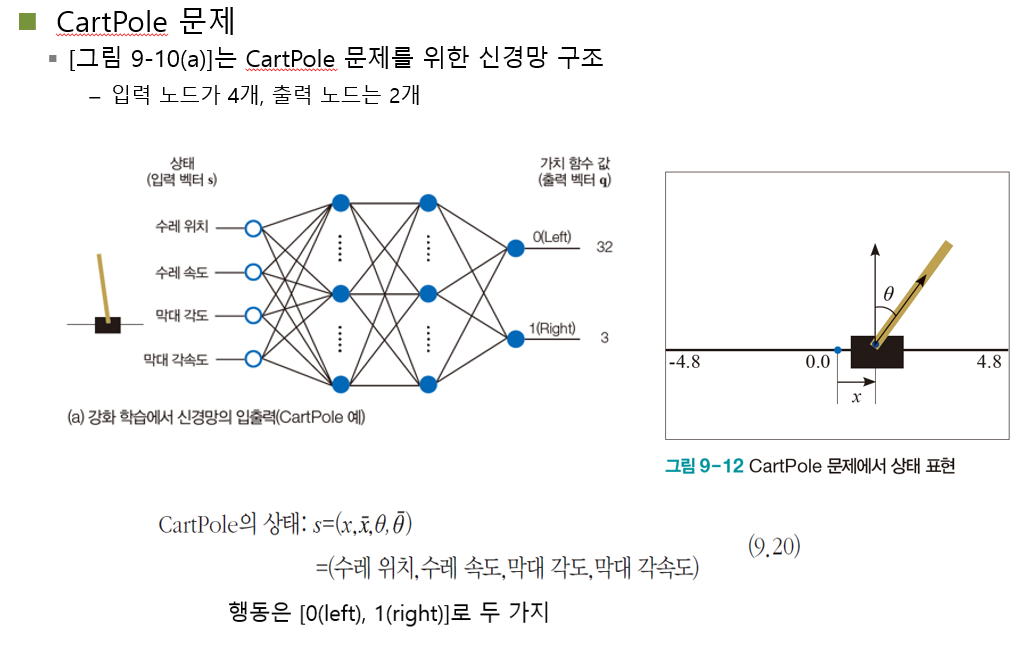

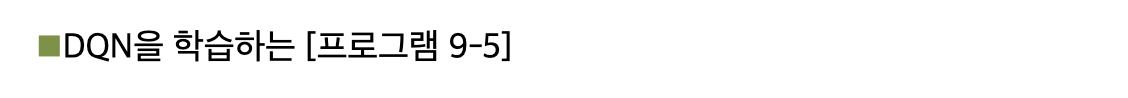

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 OpenAI Gym의 CartPole-v1 환경에서 DQN(Deep Q-Network) 알고리즘을 구현하여,
# 에이전트가 막대(pole)를 쓰러뜨리지 않고 수레(cart)를 적절히 제어하도록 학습하는 강화학습 시뮬레이션임.
# 리플레이 버퍼(deque), ε-탐욕 정책, 신경망 기반 Q 함수 근사, 타겟 갱신 없이 online Q 업데이트 방식을 포함함.
# 학습 종료 조건 설정과 함께 성능 시각화를 통해 에이전트의 학습 경향을 분석할 수 있음.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 환경 및 상태/행동 공간 설정
# 2단계: 하이퍼파라미터 및 리플레이 메모리 초기화
# 3단계: DQN 모델 정의
# 4단계: 에피소드 반복 → ε-탐욕 행동 선택 → 환경 상호작용 및 메모리 저장
# 5단계: 리플레이 버퍼 기반 배치 학습 수행
# 6단계: 학습 완료 시 모델 저장 및 점수 시각화
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계] 필요한 라이브러리 불러오기
# ------------------------------------------------------------

import numpy as np  # 수치 연산 및 배열 처리를 위한 라이브러리
import random  # 무작위 샘플링을 위한 내장 라이브러리
import gym  # OpenAI Gym 환경 사용을 위한 라이브러리
import tensorflow as tf  # 딥러닝 프레임워크
from tensorflow.keras.models import Sequential  # 순차 모델 생성 클래스
from tensorflow.keras.layers import Dense, Input  # 완전연결층 및 입력층 구성 클래스
from tensorflow.keras.optimizers import Adam  # 학습 최적화를 위한 옵티마이저
from collections import deque  # 고정 길이 큐 형태의 리플레이 메모리 구조
import matplotlib.pyplot as plt  # 학습 점수 시각화를 위한 시각화 도구

# ------------------------------------------------------------
# [2단계] 환경 및 기본 설정
# ------------------------------------------------------------

env = gym.make("CartPole-v1")  
# CartPole 환경 생성 (막대가 쓰러지지 않도록 제어하는 환경)

state_size = env.observation_space.shape[0]  
# 상태 공간 차원 수를 저장 (CartPole의 경우 4차원 상태)

action_size = env.action_space.n  
# 행동 공간의 크기를 저장 (CartPole의 경우 좌/우 이동 2가지)

max_steps = env.spec.max_episode_steps  
# 한 에피소드당 최대 스텝 수를 저장 (CartPole-v1은 500)

# ------------------------------------------------------------
# [3단계] 하이퍼파라미터 설정
# ------------------------------------------------------------

rho = 0.90  # 학습률(learning rate): 새 보상의 반영 비율
lamda = 0.99  # 할인율(discount factor): 미래 보상의 현재 가치 반영
eps = 1.0  # 초기 탐사 확률(epsilon): 처음에는 무작위 탐험에 집중
eps_decay = 0.995  # 탐사 확률 감소 비율: 점진적으로 탐험 → 이용으로 전환
eps_min = 0.01  # 최소 탐험 확률: 완전히 탐험을 제거하지 않음
batch_size = 64  # 배치 크기: 리플레이 메모리에서 학습 시 추출할 데이터 개수
n_episode = 300  # 총 에피소드 수

# ------------------------------------------------------------
# [4단계] 리플레이 메모리 및 모델 정의
# ------------------------------------------------------------

D = deque(maxlen=2000)  
# 과거 경험을 저장할 리플레이 버퍼 생성 (최대 2000개 저장)

def build_model():
    # 신경망 구조 정의 함수
    model = Sequential([
        Input(shape=(state_size,)),  # 입력층: 상태 크기만큼 입력
        Dense(32, activation='relu'),  # 은닉층 1: ReLU 활성화
        Dense(32, activation='relu'),  # 은닉층 2: ReLU 활성화
        Dense(action_size, activation='linear')  # 출력층: 각 행동에 대한 Q 값 출력
    ])
    model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))  
    # 평균제곱오차(MSE) 손실 함수와 Adam 옵티마이저 사용
    return model

model = build_model()  # DQN 모델 인스턴스 생성
scores = []  # 각 에피소드에서 얻은 점수를 저장할 리스트

# ------------------------------------------------------------
# [5단계] DQN 학습 함수 정의
# ------------------------------------------------------------

def model_learning():
    # 리플레이 메모리에서 무작위 배치 샘플링
    minibatch = random.sample(D, batch_size)

    state = np.array([x[0] for x in minibatch])  # 현재 상태 배열 추출
    action = np.array([x[1] for x in minibatch])  # 행동 배열 추출
    reward = np.array([x[2] for x in minibatch])  # 보상 배열 추출
    next_state = np.array([x[3] for x in minibatch])  # 다음 상태 배열 추출
    done = np.array([x[4] for x in minibatch])  # 종료 여부 배열 추출

    target = model.predict(state, verbose=0)  
    # 현재 상태에 대한 Q 값 예측

    target_next = model.predict(next_state, verbose=0)  
    # 다음 상태에 대한 Q 값 예측

    for i in range(batch_size):
        if done[i]:
            target[i][action[i]] = reward[i]  # 종료 시 보상만 반영
        else:
            target[i][action[i]] += rho * (reward[i] + lamda * np.amax(target_next[i]) - target[i][action[i]])  
            # Q 업데이트 식 적용 (online 업데이트)

    model.fit(state, target, batch_size=batch_size, epochs=1, verbose=0)  
    # 1회 에폭으로 신경망 학습 수행

# ------------------------------------------------------------
# [6단계] 에이전트 학습 루프
# ------------------------------------------------------------

for i in range(n_episode):
    state, _ = env.reset()  # 환경 초기화 및 상태 추출
    total_reward = 0  # 에피소드 총 보상 초기화

    while True:
        eps = max(eps_min, eps * eps_decay)  # ε 값 점진적 감소

        if np.random.rand() < eps:
            action = np.random.randint(action_size)  # 무작위 탐험
        else:
            q_values = model.predict(np.reshape(state, [1, state_size]), verbose=0)  # Q 값 예측
            action = np.argmax(q_values[0])  # 가장 큰 Q 값을 갖는 행동 선택

        next_state, reward, terminated, truncated, _ = env.step(action)  
        done = terminated or truncated  # 종료 여부 판단

        if done and total_reward < max_steps - 1:
            reward = -100  # 조기 실패 시 페널티 부여

        D.append((state, action, reward, next_state, done))  # 리플레이 메모리에 경험 저장

        if len(D) > batch_size:
            model_learning()  # 일정 경험 이상일 경우 학습 수행

        state = next_state  # 상태 갱신
        total_reward += reward  # 보상 누적

        if done:
            if total_reward != max_steps:
                total_reward += 100  # 성공적 종료 시 보상 보정
            print(f"{i}번째 에피소드 점수: {total_reward}")
            scores.append(total_reward)  # 에피소드 점수 기록
            break

    if i > 10 and np.mean(scores[-10:]) > 0.95 * max_steps:
        # 최근 10개 평균 점수가 목표 기준의 95% 이상일 경우 조기 종료
        print("성공 기준 도달. 학습 조기 종료.")
        break

# ------------------------------------------------------------
# [7단계] 모델 저장
# ------------------------------------------------------------

model.save("./cartpole_dqn_model1.h5")  
# 학습된 모델을 HDF5 형식으로 저장하여 재사용 가능하게 함

# ------------------------------------------------------------
# [8단계] 학습 점수 시각화
# ------------------------------------------------------------

plt.plot(range(1, len(scores)+1), scores)  # 에피소드별 점수 그래프
plt.title("DQN Learning Scores for CartPole-v1")  # 그래프 제목
plt.xlabel("Episode")  # x축 라벨
plt.ylabel("Score")  # y축 라벨
plt.grid()  # 격자선 표시
plt.show()  # 그래프 출력


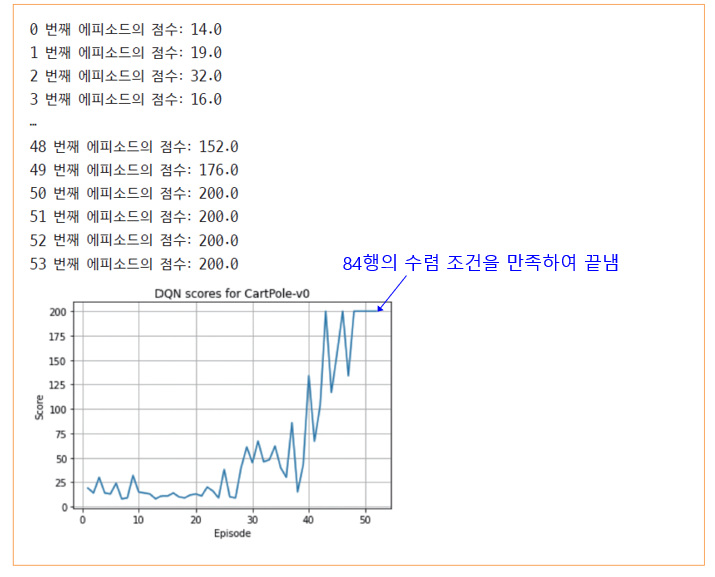

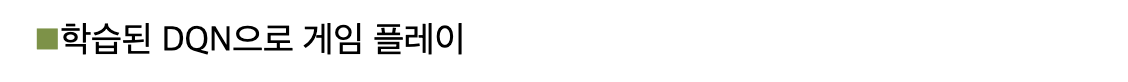

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 Colab 환경에서 학습된 DQN 모델을 불러와 CartPole-v1 환경에 적용하고,
# 예측된 행동을 수행하는 에이전트의 행동 과정을 프레임 단위로 저장하여 애니메이션 형태로 시각화함.
# 이 과정을 통해 에이전트가 학습한 정책(policy)의 실행 결과를 직관적으로 확인할 수 있음.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 필요한 패키지 설치 및 라이브러리 불러오기
# 2단계: 학습된 모델 로드
# 3단계: 환경 생성 및 초기 상태 설정
# 4단계: 모델 기반 행동 예측 및 시뮬레이션 수행
# 5단계: 렌더링된 프레임 저장
# 6단계: 전체 프레임을 애니메이션으로 시각화
# ------------------------------------------------------------

# ------------------------------------------------------------
# [1단계] 필요한 패키지 설치 (Colab 환경 전용)
# ------------------------------------------------------------

# !pip install gymnasium pygame -q  
# OpenAI Gymnasium 및 렌더링을 위한 pygame 설치
# Colab에서 CartPole의 rgb_array 렌더링 기능 사용을 위함

# ------------------------------------------------------------
# [2단계] 필요한 라이브러리 불러오기
# ------------------------------------------------------------

import numpy as np  # 수치 연산을 위한 배열 처리 라이브러리
from tensorflow.keras.models import load_model  # Keras 모델 로드 함수
import gymnasium as gym  # 최신 OpenAI Gymnasium 인터페이스 사용
import matplotlib.pyplot as plt  # 시각화를 위한 matplotlib 도구
import matplotlib.animation as animation  # 프레임 기반 애니메이션 생성 도구
from IPython.display import HTML  # Colab에서 HTML 기반 애니메이션 렌더링을 위한 모듈

# ------------------------------------------------------------
# [3단계] 학습된 모델 로드
# ------------------------------------------------------------

model = load_model('/content/drive/MyDrive/AI_2025_1st/cartpole_dqn_model1.h5', compile=False)  
# 학습된 DQN 모델 파일을 불러옴
# compile=False 옵션은 재컴파일 없이 모델 구조 및 가중치만 로드함

# ------------------------------------------------------------
# [4단계] 환경 생성 및 시뮬레이션 초기화
# ------------------------------------------------------------

env = gym.make("CartPole-v1", render_mode="rgb_array")  
# 시각화 가능한 방식(rbg_array)으로 CartPole 환경 생성
# Colab에서는 화면 렌더링 대신 이미지 프레임 배열을 생성함

state, _ = env.reset()  
# 환경 초기화 및 초기 상태(observation) 추출

long_reward = 0  
# 전체 에피소드 누적 보상 기록 변수 초기화

frames = []  
# 프레임 리스트 초기화 (각 상태에서 렌더링된 이미지를 저장)

# ------------------------------------------------------------
# [5단계] 모델 예측 기반 환경 시뮬레이션
# ------------------------------------------------------------

while True:
    q = model.predict(np.reshape(state, [1, 4]), verbose=0)  
    # 현재 상태에 대해 Q 값을 예측함
    # reshape은 (1, 4) 형태로 입력 맞춤

    action = np.argmax(q[0])  
    # Q 값이 가장 큰 행동을 선택함 (탐욕 정책)

    next_state, reward, terminated, truncated, _ = env.step(action)  
    # 선택된 행동을 환경에 적용하고 다음 상태 및 보상을 관측함

    state = next_state  
    # 현재 상태를 다음 상태로 갱신함

    long_reward += reward  
    # 누적 보상 합산

    frame = env.render()  
    # 현재 상태를 시각화 프레임(rbg_array)으로 렌더링함

    frames.append(frame)  
    # 렌더링된 프레임을 프레임 리스트에 추가함

    if terminated or truncated:  
        # 에피소드 종료 조건 확인 (막대 낙하 or 시간 초과)
        print("에피소드 점수:", long_reward)  # 최종 점수 출력
        break

env.close()  
# 환경 종료 및 자원 해제

# ------------------------------------------------------------
# [6단계] 애니메이션 시각화
# ------------------------------------------------------------

fig = plt.figure(figsize=(6, 4))  
# 시각화용 그림 객체 생성

plt.axis('off')  
# 좌표축 비활성화

im = plt.imshow(frames[0])  
# 첫 번째 프레임을 초기 이미지로 설정

def update(i):
    im.set_array(frames[i])  
    # i번째 프레임으로 이미지 업데이트
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=50)  
# 전체 프레임 수만큼 반복하여 50ms 간격으로 애니메이션 생성

HTML(ani.to_jshtml())  
# 생성된 애니메이션을 HTML 형식으로 출력하여 Colab에서 시각화


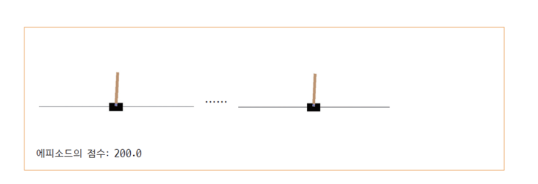